In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [8]:
df = pd.read_csv('Power_Measurements/pow19.csv', skiprows=6) #19
df = pd.DataFrame(df)
df

,Sample,Volt avg 1,Curr avg 1,Volt avg 2,Curr avg 2
0,0,5.00070,0.009427,4.99974,0.009639
1,1,5.00072,0.009433,4.99976,0.009643
2,2,5.00070,0.009434,4.99980,0.009646
3,3,5.00072,0.009435,4.99974,0.009646
4,4,5.00071,0.009436,4.99976,0.009642
...,...,...,...,...,...
13336,13336,5.00066,0.009419,4.99980,0.009643
13337,13337,5.00068,0.009427,4.99980,0.009643
13338,13338,5.00069,0.009422,4.99976,0.009636
13339,13339,5.00066,0.009426,4.99979,0.009646


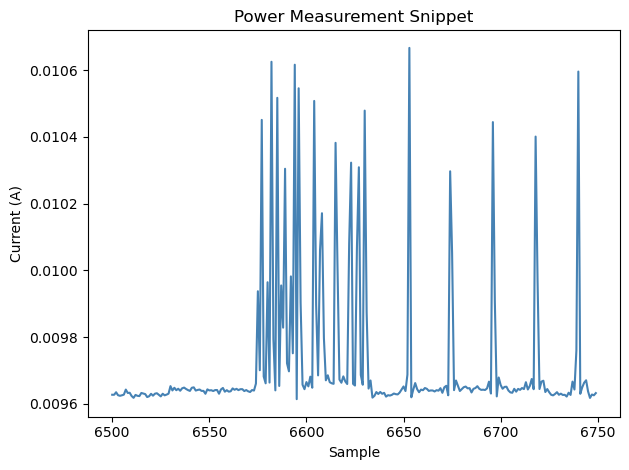

In [14]:
df['Curr avg 2'][6500:6750].plot(color='steelblue')
plt.title('Power Measurement Snippet')
plt.xlabel('Sample')
plt.ylabel('Current (A)')
plt.tight_layout()
plt.savefig('current_burst.png')
plt.show()

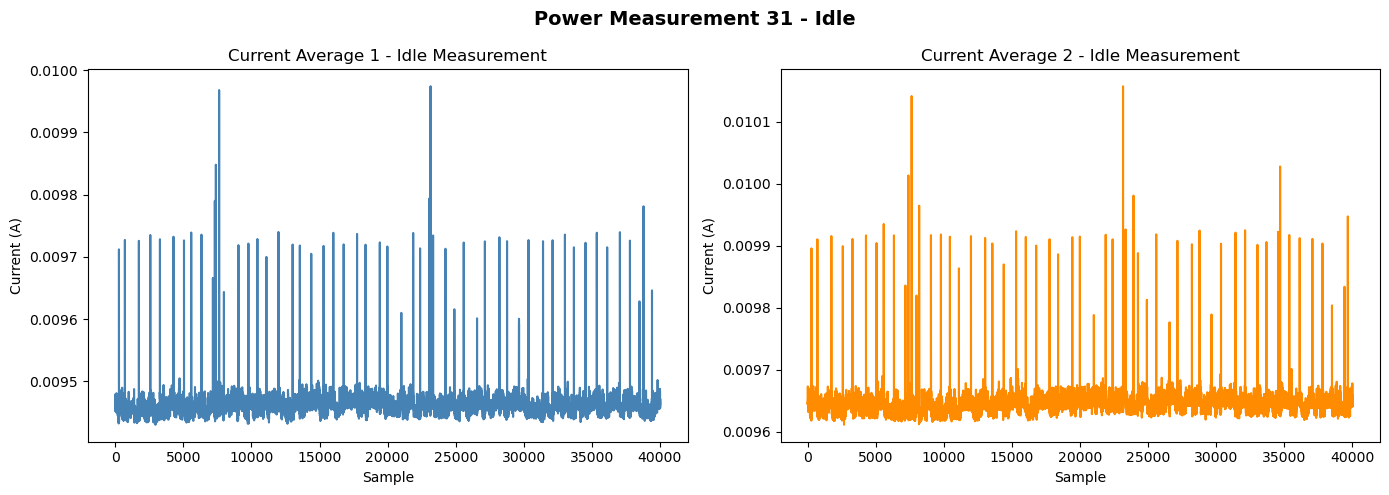

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Curr avg 1'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('Current Average 1 - Idle Measurement')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Current (A)')

df['Curr avg 2'].plot(ax=axes[1], color='darkorange')
axes[1].set_title('Current Average 2 - Idle Measurement')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Current (A)')

plt.suptitle('Power Measurement 31 - Idle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Powerplot_idle.png', dpi=150)
plt.show()

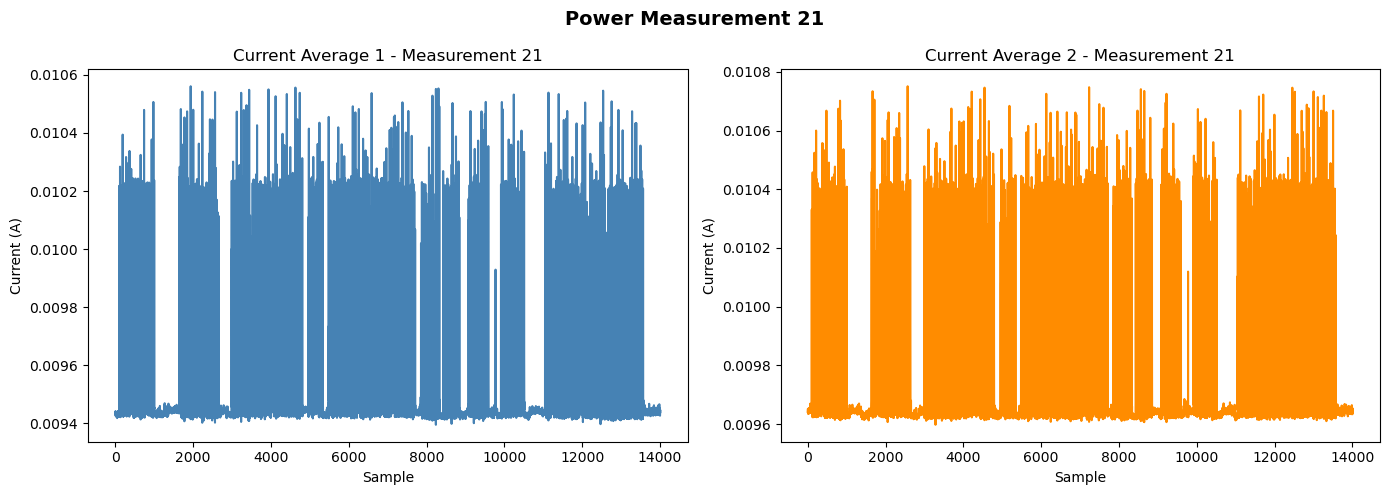

In [128]:
dfs = {}
for i in range(1, 31):
    if i == 15 or i == 23:
        continue
    dfs[i] = pd.read_csv(f'Power_Measurements/pow{i}.csv', skiprows=6)
    dfs[i].drop(columns=["Sample"], axis=1, inplace=True)
n = 21
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dfs[n]['Curr avg 1'].plot(ax=axes[0], color='steelblue')
axes[0].set_title(f'Current Average 1 - Measurement {n}')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Current (A)')

dfs[n]['Curr avg 2'].plot(ax=axes[1], color='darkorange')
axes[1].set_title(f'Current Average 2 - Measurement {n}')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Current (A)')

plt.suptitle(f'Power Measurement {n}', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig(f'Powerplot_dfs{n}.png', dpi=150)
plt.show()
#plt.savefig(f"Powerplot_dfs{i}")

In [117]:
minimum1 = dfs[21]['Curr avg 1'].min()
maximum1 = dfs[21]['Curr avg 1'].max()
minimum2 = dfs[21]['Curr avg 2'].min()
maximum2 = dfs[21]['Curr avg 2'].max()
print(f"1\n============\nMinimum: {minimum1}\nMaximum: {maximum}\n\n2\n============\nMinimum: {minimum2}\nMaximum: {maximum2}")

1
Minimum: 0.00939472
Maximum: 0.0105609

2
Minimum: 0.00959767
Maximum: 0.0107509


In [ ]:
#proposal, concerning the energy consumption, just take the minimum and the maximum of every measuremnt and build confidence interval based on this
#shows us, during normal operation when a nodes are always on, the powerconsumption will fluctuate like this, this is a good indicator for hardware specification

In [131]:
from scipy import stats
import numpy as np

mins, maxs = [], []

for i in list(dfs.keys())[10:31]:
    available_channels = [col for col in dfs[i].columns if 'Curr avg' in col]
    for ch in available_channels:
        series = dfs[i][ch]
        mins.append(series.min())
        maxs.append(series.max())

mins = np.array(mins)
maxs = np.array(maxs)

for label, data in [('Minimum current (baseline)', mins), ('Maximum current (peaks)', maxs)]:
    mean = data.mean()
    se = stats.sem(data)
    n = len(data)
    print(f"\n{label}  |  n={n}  |  mean={mean*1000:.4f} mA")
    for cl in [0.90, 0.95, 0.99]:
        t_crit = stats.t.ppf((1 + cl) / 2, df=n - 1)
        margin = t_crit * se
        print(f"  {int(cl*100)}% CI: [{(mean-margin)*1000:.4f}, {(mean+margin)*1000:.4f}] mA  (±{margin*1000:.4f})")


Minimum current (baseline)  |  n=36  |  mean=9.5080 mA
  90% CI: [9.4821, 9.5339] mA  (±0.0259)
  95% CI: [9.4769, 9.5392] mA  (±0.0311)
  99% CI: [9.4662, 9.5498] mA  (±0.0418)

Maximum current (peaks)  |  n=36  |  mean=10.5855 mA
  90% CI: [10.5132, 10.6578] mA  (±0.0723)
  95% CI: [10.4987, 10.6724] mA  (±0.0869)
  99% CI: [10.4690, 10.7021] mA  (±0.1165)


In [129]:
count = 0
for i in list(dfs.keys())[10:31]:  # [10:] gives you from the 11th key onwards
    available_channels = [col for col in dfs[i].columns if 'Curr avg' in col]
    print(f"dfs[{i}]: {len(available_channels)} channels")
    count += len(available_channels)
print(f"\nTotal n = {count}")

dfs[11]: 2 channels
dfs[12]: 2 channels
dfs[13]: 2 channels
dfs[14]: 2 channels
dfs[16]: 2 channels
dfs[17]: 2 channels
dfs[18]: 2 channels
dfs[19]: 2 channels
dfs[20]: 2 channels
dfs[21]: 2 channels
dfs[22]: 2 channels
dfs[24]: 2 channels
dfs[25]: 2 channels
dfs[26]: 2 channels
dfs[27]: 2 channels
dfs[28]: 2 channels
dfs[29]: 2 channels
dfs[30]: 2 channels

Total n = 36


In [121]:
for i in dfs.keys():
    results[i] = {}
    available_channels = [col for col in dfs[i].columns if 'Curr avg' in col]

    for ch in available_channels:
        series = dfs[i][ch]
        baseline = series.min()
        dynamic_range = series.max() - baseline
        threshold_offset = dynamic_range * 0.3  # 30% of range
        threshold = baseline + threshold_offset

        above = series > threshold
        is_new_spike = above & ~above.shift(1, fill_value=False)
        groups = is_new_spike.cumsum()
        peaks = series[above].groupby(groups[above]).max()

        n = len(peaks)

        print(f"\nMeasurement {i} | {ch}")
        print(f"  Baseline: {baseline:.6f} A | Max: {series.max():.6f} A | Range: {dynamic_range*1000:.4f} mA")
        print(f"  Threshold: {threshold:.6f} A | Packets detected: {n}")

        if n < 2:
            print(f"  Still too few spikes — inspect this measurement manually")
            continue

        mean = peaks.mean()
        se = stats.sem(peaks)
        results[i][ch] = {'n_packets': n, 'mean_peak': mean, 'baseline': baseline}

        for cl in [0.90, 0.95, 0.99]:
            t_crit = stats.t.ppf((1 + cl) / 2, df=n - 1)
            margin = t_crit * se
            print(f"  {int(cl*100)}% CI: [{mean-margin:.6f}, {mean+margin:.6f}] A  (±{margin:.6f})")


Measurement 1 | Curr avg 1
  Baseline: 0.009596 A | Max: 0.010043 A | Range: 0.4467 mA
  Threshold: 0.009730 A | Packets detected: 501
  90% CI: [0.009925, 0.009931] A  (±0.000003)
  95% CI: [0.009924, 0.009932] A  (±0.000004)
  99% CI: [0.009923, 0.009933] A  (±0.000005)

Measurement 2 | Curr avg 1
  Baseline: 0.009586 A | Max: 0.010103 A | Range: 0.5168 mA
  Threshold: 0.009741 A | Packets detected: 500
  90% CI: [0.009909, 0.009916] A  (±0.000004)
  95% CI: [0.009908, 0.009916] A  (±0.000004)
  99% CI: [0.009906, 0.009918] A  (±0.000006)

Measurement 3 | Curr avg 1
  Baseline: 0.009585 A | Max: 0.010058 A | Range: 0.4731 mA
  Threshold: 0.009727 A | Packets detected: 500
  90% CI: [0.009914, 0.009921] A  (±0.000003)
  95% CI: [0.009913, 0.009922] A  (±0.000004)
  99% CI: [0.009912, 0.009923] A  (±0.000005)

Measurement 4 | Curr avg 1
  Baseline: 0.009587 A | Max: 0.010098 A | Range: 0.5113 mA
  Threshold: 0.009741 A | Packets detected: 500
  90% CI: [0.009911, 0.009918] A  (±0.0000

In [15]:
minimum = df['Curr avg 1'].min()
maximum = df['Curr avg 1'].max()
print(f"Minimum: {minimum}\nMaximum: {maximum}")

Minimum: 0.00959629
Maximum: 0.010043
